## 授權與來源（License & Attribution）

本課程自編／改編的程式與文字：Copyright 2026 leonjyentub；Apache License 2.0（`../LICENSE`）。
教學概念與來源參照：Aurélien Géron, `ageron/handson-mlp` Ch.13 RNN 與時間序列，上游 Apache-2.0，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
本檔改編／創作說明：依原書概念另編可於 CPU 執行的小型機制實驗、示範圖表與中文教學解釋；不等同於完整上游實驗，亦不表示每段程式均直接複製上游。
詳細對照：`../SOURCES.md`；授權及署名：`../THIRD_PARTY_NOTICES.md`。
其他第三方資料、圖片及模型權利按各自來源處理，不包含在本課程程式授權中。

# 16｜序列模型_RNN與時間序列預測

把連續時間序列切成視窗，嚴格使用過去預測下一步。

對應 `slides/16_序列模型_RNN與時間序列預測.md`；從第一格依序執行即可重現投影片中的表格與圖。

## 來源與改編界線

- Aurélien Géron，`handson-mlp/13_processing_sequences_using_rnns_and_cnns.ipynb`，固定 commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`，參考 Cells 19–35、47–62（時間序列、視窗與 Simple RNN）。

- 本 Notebook 為課堂短實驗：保留核心張量、演算法或評估流程，改用 NumPy／scikit-learn 與小型資料，讓 CPU 能快速重跑。
- 圖表與數值是本檔實際執行結果，不代表原書完整模型成效。原始程式授權與歸屬見 `../NOTICE.md`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import SEED, setup, savefig, report
setup()
rng = np.random.default_rng(SEED)

## 課堂小實驗

In [2]:
from sklearn.linear_model import LinearRegression
t = np.arange(240)
series = np.sin(t / 12) + 0.35 * np.sin(t / 3.5) + rng.normal(0, 0.08, len(t))
window = 12
X = np.stack([series[i:i+window] for i in range(len(series)-window)])
y = series[window:]
split = 170
model = LinearRegression().fit(X[:split], y[:split])
pred = model.predict(X[split:])
persistence = X[split:, -1]
rmse = lambda a,b: float(np.sqrt(np.mean((a-b)**2)))
pd.Series({'window_model_RMSE': rmse(y[split:], pred), 'persistence_RMSE': rmse(y[split:], persistence)})

window_model_RMSE    0.119706
persistence_RMSE     0.141599
dtype: float64

## 執行結果圖

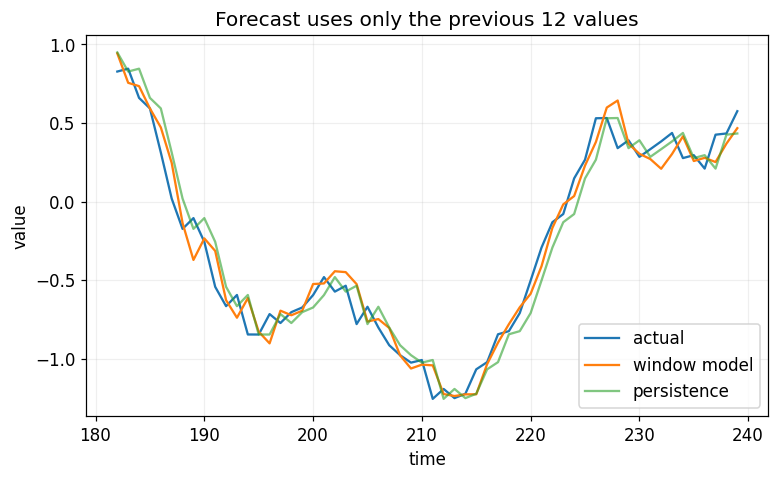

In [3]:
idx = np.arange(split+window, len(series))
plt.plot(idx, y[split:], label='actual')
plt.plot(idx, pred, label='window model')
plt.plot(idx, persistence, alpha=.6, label='persistence')
plt.xlabel('time'); plt.ylabel('value'); plt.title('Forecast uses only the previous 12 values')
plt.legend()
savefig('16_sequence_demo')
report('sequence_forecast', {'window_RMSE': rmse(y[split:], pred), 'persistence_RMSE': rmse(y[split:], persistence)})

## 解讀與延伸

先描述圖或表直接支持的結果，再說明這個縮編實驗不能代表完整模型的哪些面向。